# [LAB-02] 7. DBSCAN - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame, crosstab
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


## 📚 무리 성격을 흐리는 거래처가 있다 — 밀집도로 걸러낼 수 있을까

### 당신은 도매 거래처 440곳을 3개 무리로 나눠 보고한 그 담당자입니다.

지난 보고에서 당신은 여섯 항목의 지출 패턴만으로 거래처를 3개로 나눴고 무리마다 담당자를 한 명씩 붙이는 안을 올렸습니다. 배정을 준비하던 팀장이 이번에는 이렇게 되묻습니다. "무리마다 성격이 영 다른 거래처가 몇 곳씩 섞여 있다. 이런 곳은 담당자를 붙이기 전에 따로 빼 두는 게 낫지 않겠나."

그래서 이번에는 중심점이나 나무가 아니라 **밀집도**로 접근합니다. 반경 안에 이웃이 몇 곳이나 있는지를 세어 빽빽한 자리는 무리로 묶고 어디에도 끼지 못하는 거래처는 따로 빼 두는 방법입니다. 데이터 준비는 지난번과 같습니다 — 채널·지역은 빼고, 큰 거래처 때문에 치우친 지출액을 완만하게 만든 뒤 표준화합니다.

어디에도 속하지 못하는 거래처가 몇 곳이고 어디에서 나왔는지 찾아낸 다음, 그 거래처들을 실제로 빼는 것이 나은지까지 판단하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [2]:
origin = load_data("wholesale_customers")
origin.head()

📚 이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)



컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### 전처리 (채널·지역 제외 / 치우침 완화 / 표준화)

In [3]:
df1 = origin.drop(columns=["Channel", "Region"])

# 몇몇 큰 거래처 때문에 한쪽으로 심하게 치우친 금액을 완만하게 만든 뒤 표준화한다
df2 = my_prep.log_transform(df1, log_columns=list(df1.columns), verbose=False)
sdf = my_prep.scaling(df2, method="standard", verbose=False)

print(f"군집분석에 사용할 변수 개수: {sdf.shape[1]}개")

sdf.head()

군집분석에 사용할 변수 개수: 6개


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.485,0.976,0.439,-1.508,0.643,0.408
1,0.089,0.991,0.650,0.135,0.764,0.624
2,0.018,0.891,0.454,0.377,0.802,1.758
3,0.516,-0.958,-0.084,1.140,-0.324,0.629
4,0.877,0.440,0.395,0.757,0.405,1.442


#### 기본값 그대로 적합

In [4]:
# 이미 스케일링을 마쳤으므로 scaling=None (DBSCAN 은 랜덤 요소가 없다)
estimator0, dbf0, summary0 = my_cluster.dbscan(sdf, eps=0.5, min_samples=5,
                                              scaling=None, plot=False)

[DBSCAN] eps = 0.5, min_samples = 5, 거리 = euclidean
  · 군집 수 = 1개 (노이즈 제외)
  · 노이즈 = 435개 (전체의 98.9%)


,그룹번호,데이터수,비율(%),핵심벡터,외곽벡터
0,-1,435,98.900,0,0
1,0,5,1.100,1,4


#### 반경을 넓혀 가며 노이즈 비율 확인

In [5]:
items = []

for eps in [0.5, 1.0, 1.5, 2.0, 2.5]:
    e = DBSCAN(eps=eps, min_samples=5, n_jobs=-1).fit(sdf)
    labels = e.labels_
    n_noise = int((labels == -1).sum())

    items.append({"eps": eps,
                  "군집수": len(set(labels)) - (1 if -1 in labels else 0),
                  "노이즈": n_noise,
                  "노이즈비율(%)": round(n_noise / len(labels) * 100, 1)})

DataFrame(items)

,eps,군집수,노이즈,노이즈비율(%)
0,0.500,1,435,98.900
1,1.000,1,124,28.200
2,1.500,1,41,9.300
3,2.000,1,15,3.400
4,2.500,1,5,1.100


#### 채택한 반경으로 최종 적합 (핵심 / 외곽 / 노이즈 시각화)

[DBSCAN] eps = 2.0, min_samples = 5, 거리 = euclidean
  · 군집 수 = 1개 (노이즈 제외)
  · 노이즈 = 15개 (전체의 3.4%)


,그룹번호,데이터수,비율(%),핵심벡터,외곽벡터
0,-1,15,3.400,0,0
1,0,425,96.600,410,15


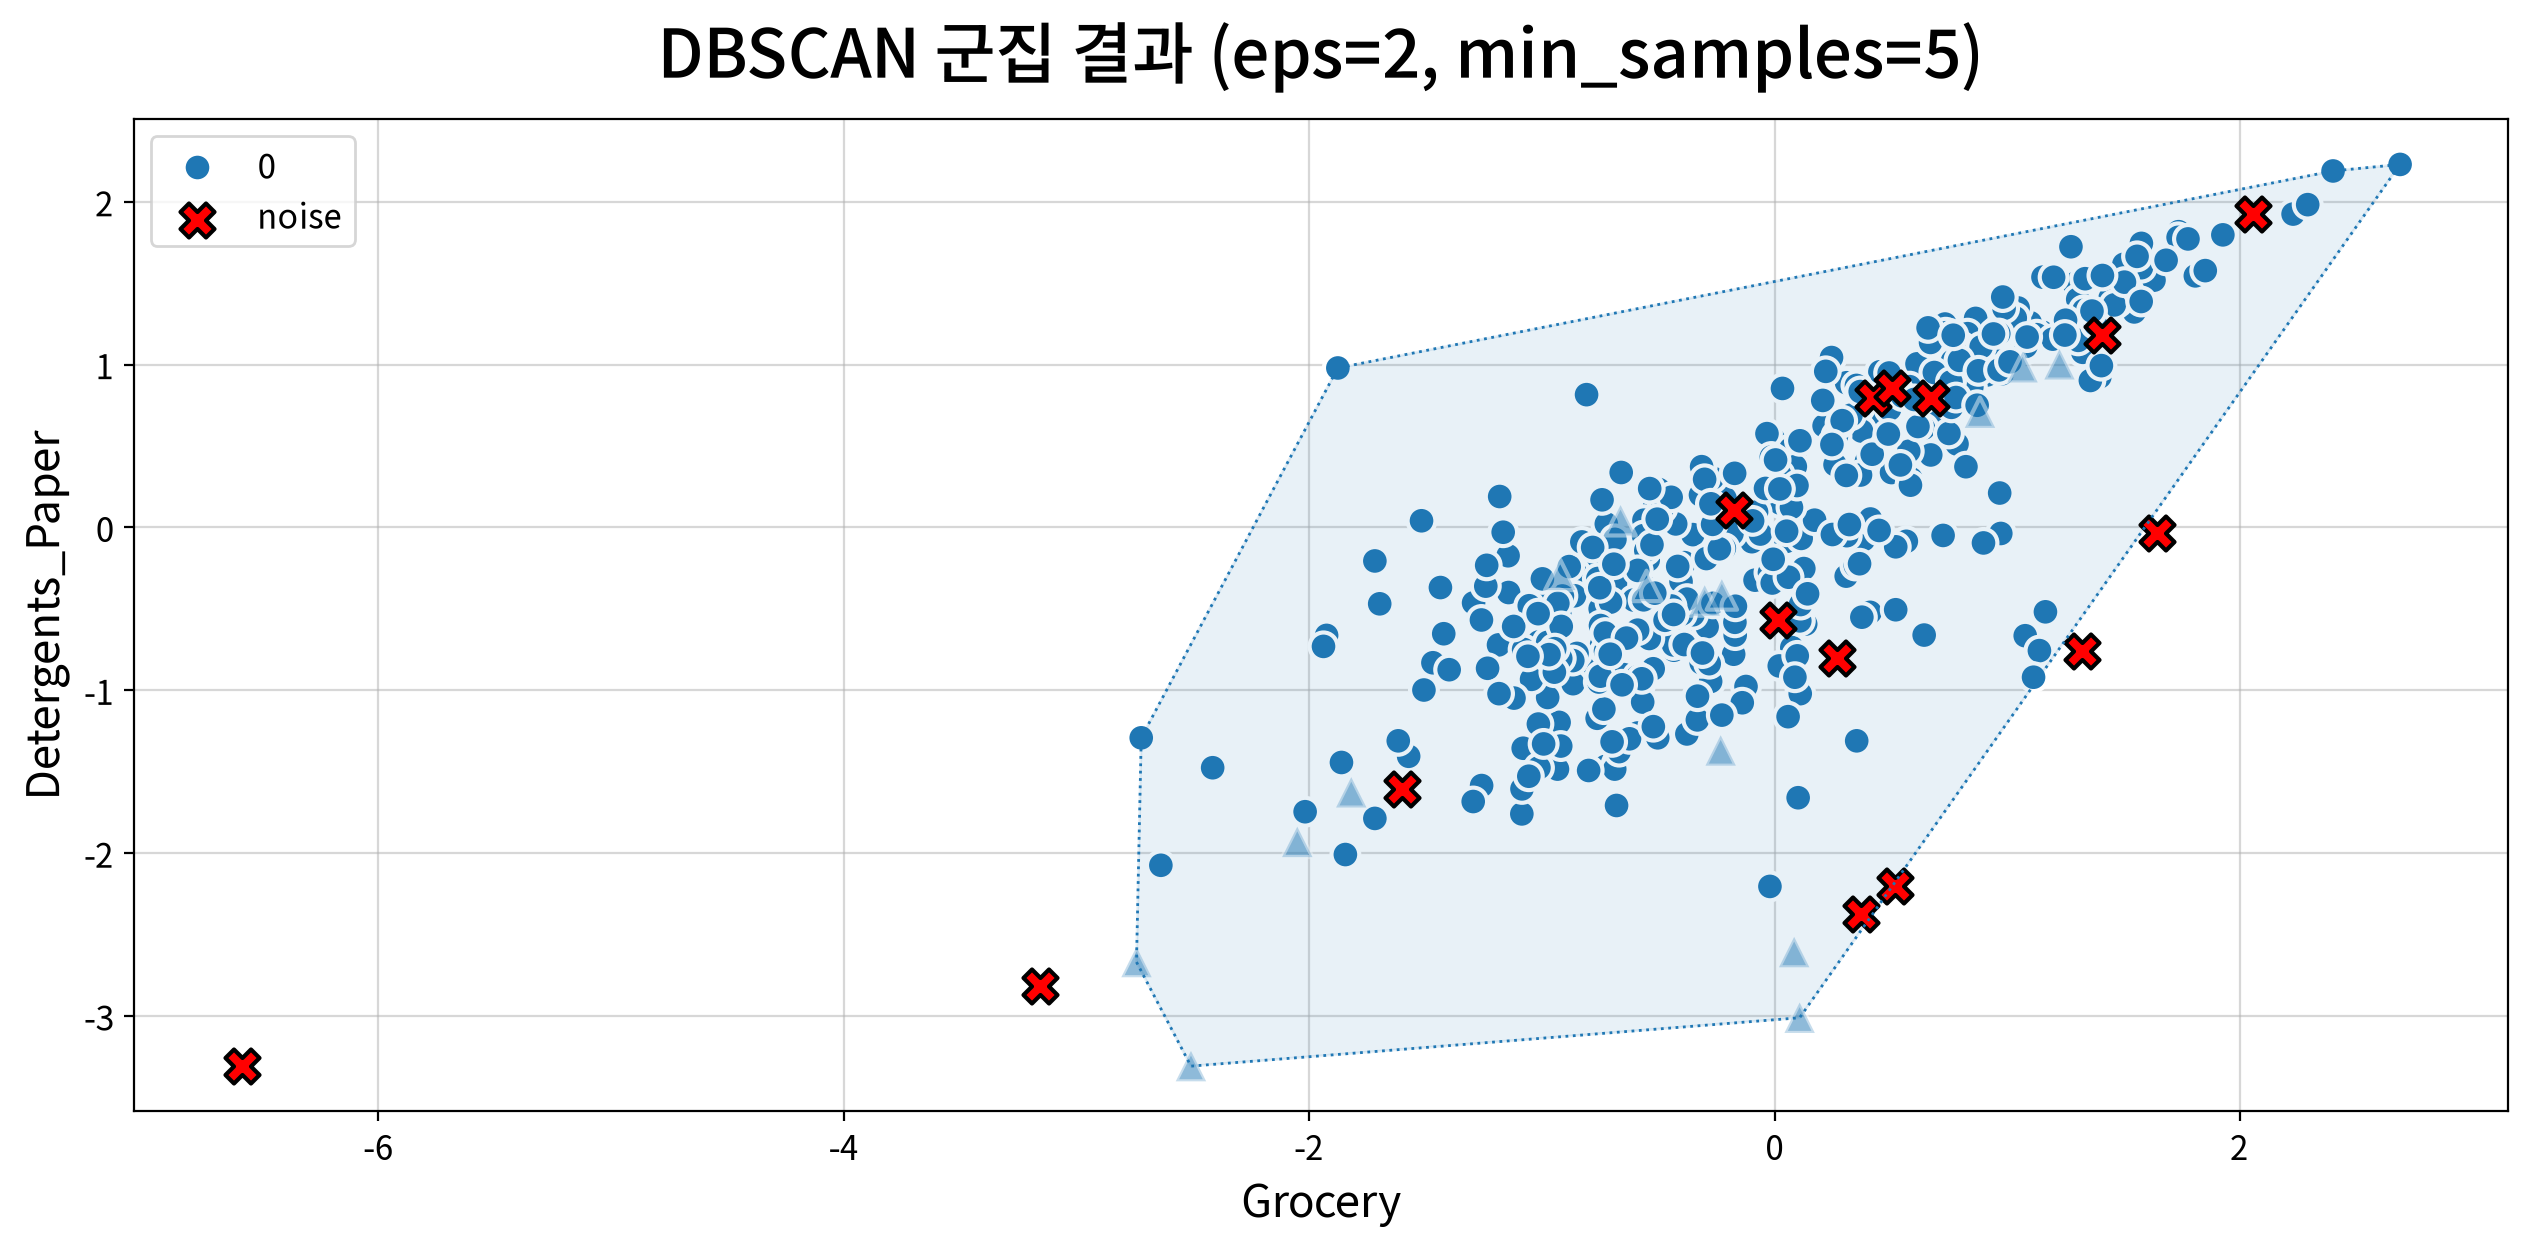

In [6]:
estimator, dbf, summary = my_cluster.dbscan(sdf, eps=2.0, min_samples=5, scaling=None,
                                           x="Grocery", y="Detergents_Paper")

#### 지난번 3개 무리와 맞대어 보기

In [7]:
estimator_h, hdf = my_cluster.agglomerative(sdf, k=3, scaling=None, verbose=False, plot=False)

print("[계층적 3개(행) × DBSCAN(열)]")
print(crosstab(hdf["그룹번호"], dbf["그룹번호"]).to_string())

[계층적 3개(행) × DBSCAN(열)]
그룹번호  -1    0
그룹번호         
0      4  230
1     10   80
2      1  115


#### 노이즈를 빼고 다시 3개로 나눠 보기

In [8]:
keep = dbf["그룹번호"] != -1

estimator_h2, hdf2 = my_cluster.agglomerative(sdf[keep], k=3, scaling=None,
                                             verbose=False, plot=False)

print(f"440곳 전부  : {silhouette_score(X=sdf, labels=estimator_h.labels_):.4f}")
print(f"노이즈 제외 : {silhouette_score(X=sdf[keep], labels=estimator_h2.labels_):.4f}")

440곳 전부  : 0.2350
노이즈 제외 : 0.1999


### 문제 풀이

#### 1. 이웃으로 인정할 반경과 최소 이웃 수를 라이브러리 기본값 그대로 두고 돌렸을 때, 어느 무리에도 속하지 못한 거래처는 몇 곳인가요? (곳)

- **정답**: `435`
- **복습 개념**: 밀집도 기반 군집화는 "반경 안에 몇 곳이 있는가"를 세는 방법이므로 어느 무리에도 속하지 못한 데이터를 -1로 남깁니다. 이 -1이 곧 노이즈이며 다른 방법과 달리 모든 데이터를 억지로 어딘가에 배정하지 않는 것이 이 방법의 특징입니다.
- **풀이 접근**: 지난번과 같은 방식으로 전처리한 데이터에 반경과 최소 이웃 수를 기본값 그대로 두고 군집화한 뒤, 군집 번호가 -1인 데이터의 개수를 셉니다.
- **근거(계산 결과)**: 출력의 `노이즈 = 435개 (전체의 98.9%)`입니다. 무리로 묶인 거래처는 단 5곳이며 그중 반경 조건을 채운 곳은 1곳뿐입니다.
- **자주 하는 실수**: 스케일링을 했으니 기본값을 그대로 써도 되겠다고 생각하기 쉽습니다. 그런데 반경 0.5는 변수가 2개일 때를 염두에 둔 값이고 지금은 변수가 6개입니다. 차원이 늘어날수록 같은 반경 안에 들어오는 이웃은 급격히 줄어들기 때문에 표준화를 마친 데이터라도 반경은 데이터에 맞춰 다시 정해야 합니다.

#### 2. 반경을 0.5부터 2.5까지 0.5씩 넓혀 가며 확인할 때, 어디에도 속하지 못한 거래처의 비율이 처음으로 5% 아래로 내려가는 반경은 얼마인가요? (소수 첫째 자리)

- **정답**: `2.0`
- **복습 개념**: 반경은 밀집도 기반 군집화에서 가장 중요한 값입니다. 반경이 너무 작으면 대부분이 노이즈가 되고 너무 크면 떨어져 있어야 할 무리까지 하나로 이어집니다.
- **풀이 접근**: 최소 이웃 수는 그대로 두고 반경만 0.5씩 키워 가며 군집화를 반복합니다. 반경마다 군집 수와 노이즈 개수를 모아 표로 만든 뒤, 노이즈 비율이 5%를 밑도는 첫 줄을 읽습니다.
- **근거(계산 결과)**: 노이즈 비율은 반경 0.5에서 98.9%, 1.0에서 28.2%, 1.5에서 9.3%로 줄어들다가 2.0에서 **3.4%**가 되어 처음으로 5% 아래로 내려갑니다. 2.5까지 키우면 1.1%까지 떨어집니다.
- **함께 생각해 볼 점**: 반경을 계속 키우면 노이즈는 얼마든지 줄일 수 있습니다. 극단적으로 반경을 아주 크게 잡으면 440곳이 전부 한 무리가 되고 노이즈는 0곳이 됩니다. 노이즈가 적은 것이 좋은 결과라는 뜻은 아니라는 점을 기억하세요. 반경을 눈대중으로 고르는 대신 이웃까지의 거리 분포를 보고 정하는 방법은 다음 단원에서 다룹니다.

#### 3. 그 반경으로 다시 나눴을 때, 반경 안에 최소 이웃 수를 채워 무리의 몸통을 이루는 거래처는 몇 곳인가요? (곳)

- **정답**: `410`
- **복습 개념**: 밀집도 기반 군집화는 무리에 속한 데이터를 다시 둘로 나눕니다. 반경 안에 최소 이웃 수를 채운 데이터가 핵심 벡터입니다. 스스로는 그 조건을 못 채우지만 핵심 벡터의 반경 안에 들어와 무리에 얹혀 있는 데이터가 외곽 벡터입니다.
- **풀이 접근**: 채택한 반경으로 다시 군집화한 뒤, 모델이 알려 주는 핵심 벡터의 위치 번호를 이용해 각 거래처를 핵심·외곽·노이즈로 나누고 그 개수를 셉니다.
- **근거(계산 결과)**: 요약표에서 0번 무리 425곳은 핵심 벡터 **410곳**과 외곽 벡터 15곳으로 나뉩니다. 노이즈 15곳은 어느 무리에도 속하지 않으므로 두 유형 모두 0입니다.
- **헷갈리기 쉬운 점**: 외곽 벡터 15곳과 노이즈 15곳은 개수가 같을 뿐 전혀 다릅니다. 외곽 벡터는 무리에 속한 거래처이고 노이즈는 어디에도 속하지 않은 거래처입니다. 둘을 가르는 기준은 자기 반경 안의 이웃 수가 아니라 "핵심 벡터의 반경 안에 들어와 있는가"입니다.

#### 4. 이번에 어디에도 속하지 못한 거래처를 지난번 3개 무리와 맞대어 보면 한 무리에 유독 몰려 있습니다. 그 무리에서 빠져나간 거래처는 몇 곳인가요? (곳)

- **정답**: `10`
- **복습 개념**: 군집 결과를 다른 방법의 결과와 대조해 읽는 단계입니다. 두 결과의 무리 번호로 교차표를 만들면 어느 무리가 어떻게 흩어졌는지가 한눈에 보입니다.
- **풀이 접근**: 지난번과 같은 방식으로 3개 무리를 다시 만든 뒤, 그 무리 번호와 이번 군집 번호로 교차표를 만듭니다. 표에서 -1 열을 세로로 훑어 값이 가장 큰 행을 읽습니다.
- **근거(계산 결과)**: 교차표의 -1 열은 0번 무리 4곳, 1번 무리 **10곳**, 2번 무리 1곳입니다. 1번 무리는 90곳뿐인 작은 무리이므로 열에 한 곳 이상이 빠져나간 셈입니다.
- **실무 포인트**: 1번 무리는 지난 단원에서 2개를 3개로 늘릴 때 새로 갈라져 나온 그 무리이고 소매점 비중이 가장 높았던 무리이기도 합니다. 팀장이 "성격이 다른 거래처가 섞여 있다"고 말한 무리가 어디였는지 짐작이 되는 대목입니다.

#### 5. 어디에도 속하지 못한 거래처를 모두 빼고 나머지만 다시 3개로 나눴을 때, 자기 무리와는 가깝고 옆 무리와는 먼 정도를 나타내는 점수는 얼마인가요? (소수 셋째 자리)

- **정답**: `0.200`
- **복습 개념**: 이상치를 걸러낸 뒤 군집 품질이 실제로 좋아졌는지 확인하는 단계입니다. 걸러내기 전후의 실루엣 점수를 같은 조건에서 비교합니다.
- **풀이 접근**: 노이즈로 지목된 거래처를 뺀 데이터로 다시 3개 무리를 만들고 실루엣 점수를 구합니다. 지난번 440곳 전부로 3개를 나눴을 때의 점수와 나란히 놓고 비교합니다.
- **근거(계산 결과)**: 440곳 전부로 나눴을 때 0.235였던 점수가 15곳을 뺀 뒤에는 **0.200**으로 내려갑니다.
- **결론**: 튀는 데이터를 빼면 결과가 깔끔해질 것 같지만 이 데이터에서는 반대였습니다. 15곳이 무리 사이의 빈 공간을 메우고 있던 것이 아니라, 무리의 경계를 벌려 놓는 역할을 하고 있었기 때문입니다. 팀장에게 보고할 답은 "빼자"가 아니라 "빼도 무리가 더 또렷해지지는 않는다"입니다. 다만 이 15곳은 신선식품을 거의 사지 않으면서 식료품만 사 가는 등 지출 구성이 확실히 남다르므로 무리에서 제외하는 대신 담당자를 따로 두거나 개별 관리 대상으로 올리는 편이 낫습니다. 그리고 반경 2.0은 노이즈 비율만 보고 고른 값이라는 점도 함께 보고해야 합니다. 근거를 갖춰 반경을 정하는 방법은 다음 단원에서 배웁니다.